In [31]:
# importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# Loading the data set
data_set = pd.read_csv('adult.csv')
# printdata_set.head())
print(data_set.info())
print(data_set.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None
                age        fnlwgt  education.num  capital.gain  capital.loss  \
count  3

Text(0, 0.5, 'Frequency')

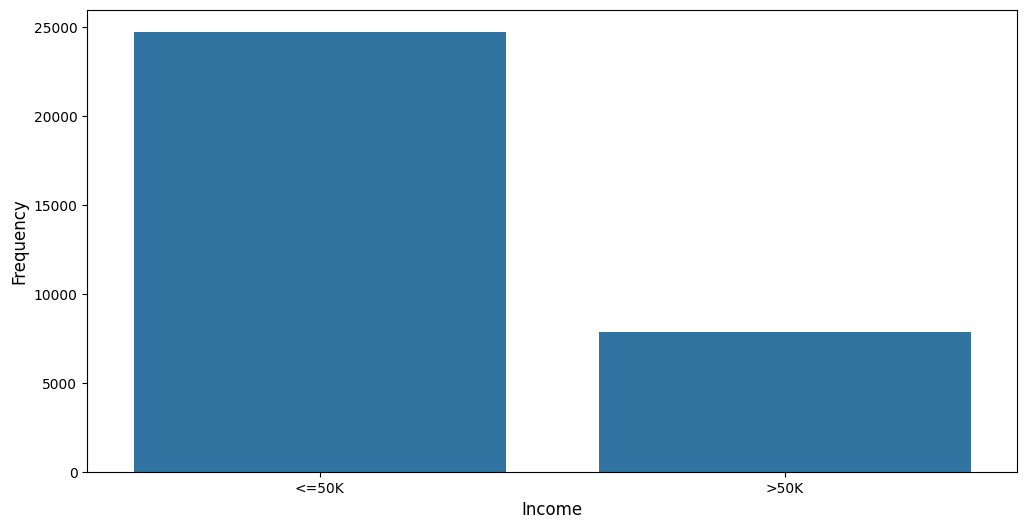

In [33]:
plt.figure(figsize =(12,6))
sns.countplot(x = 'income', data = data_set)
plt.xlabel("Income",fontsize = 12)
plt.ylabel("Frequency",fontsize = 12)

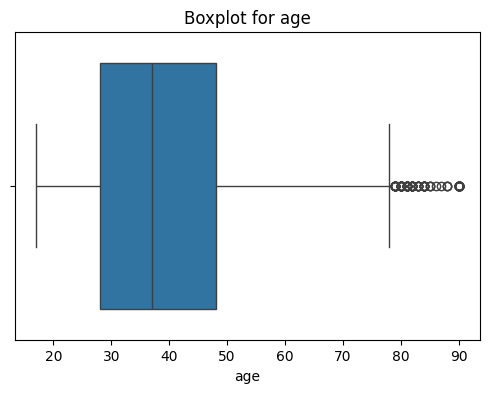

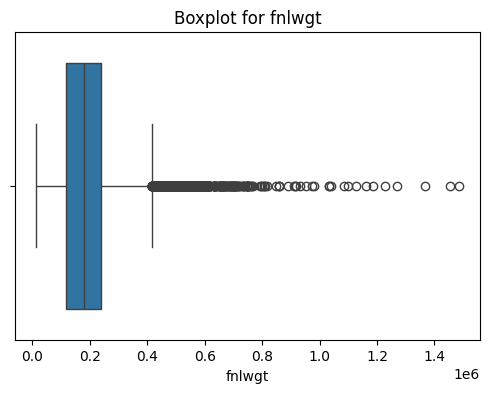

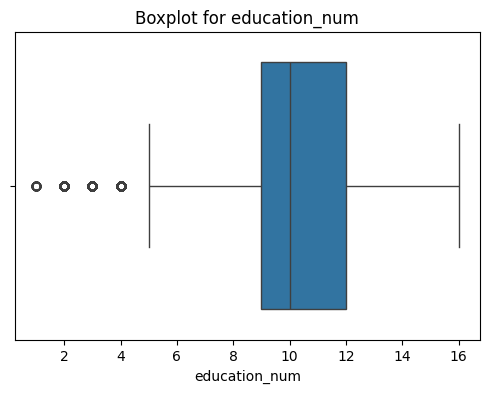

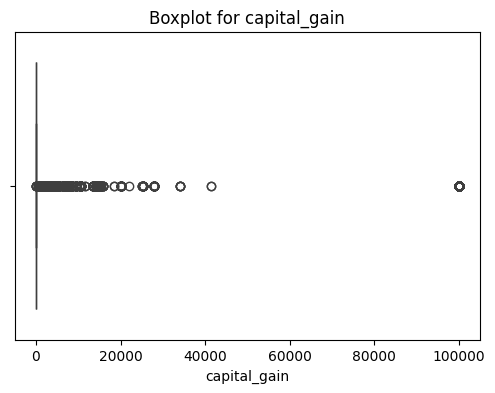

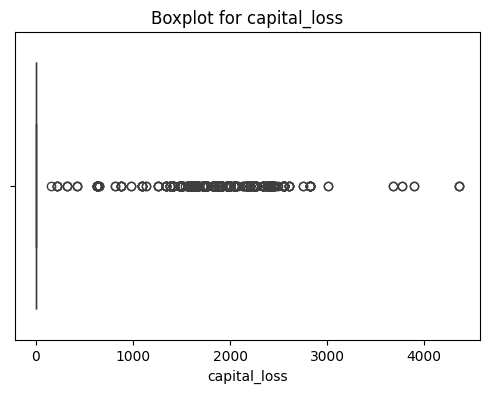

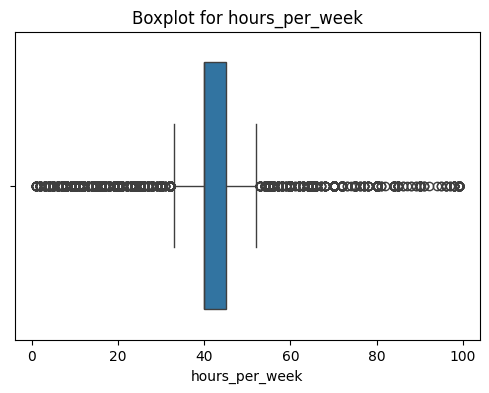

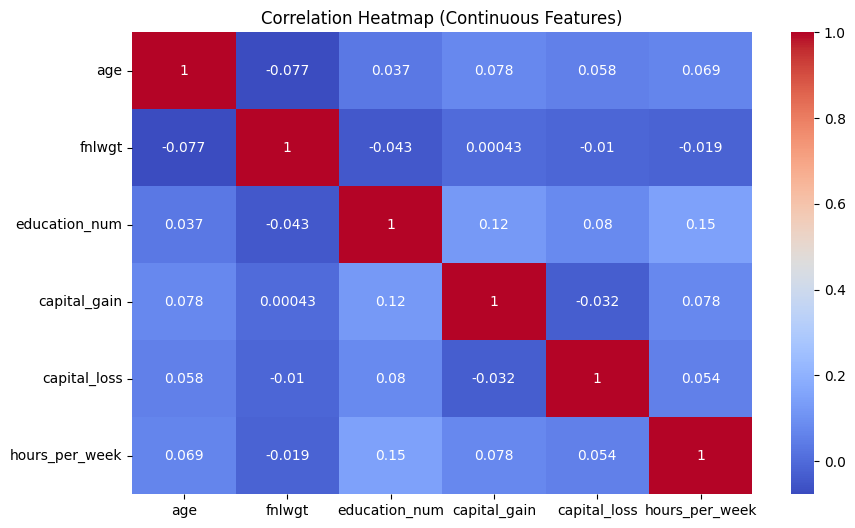

In [34]:
# Draw some visualization plots


# converting column names for ease
data_set.columns = [col.strip().lower().replace('.', '_') for col in data_set.columns]

# Box plots for continuous variables
continuous_features = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

for feature in continuous_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data_set[feature])
    plt.title(f'Boxplot for {feature}')
    plt.show()

# Heatmap for Pearson Correlation between continuous features
plt.figure(figsize=(10, 6))
sns.heatmap(data_set[continuous_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Continuous Features)')
plt.show()


Text(0.5, 0, 'Workclass')

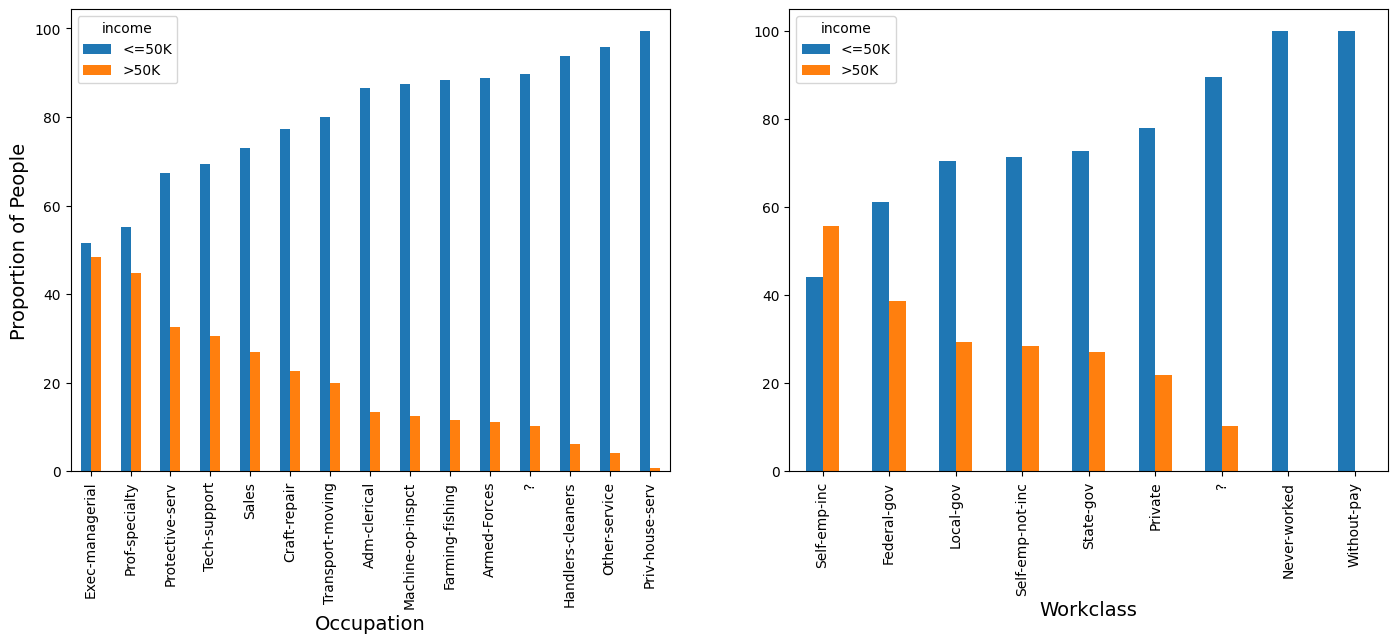

In [35]:
table_occu = pd.crosstab(data_set['occupation'], data_set['income'])
table_workclass = pd.crosstab(data_set['workclass'], data_set['income'])
table_edu = pd.crosstab(data_set['education'], data_set['income'])
table_marital = pd.crosstab(data_set['marital_status'], data_set['income'])
table_race = pd.crosstab(data_set['race'], data_set['income'])
table_sex = pd.crosstab(data_set['sex'], data_set['income'])
table_country = pd.crosstab(data_set['native_country'], data_set['income'])

fig = plt.figure(figsize = (17,6))

ax = fig.add_subplot(1,2,1)
(table_occu.div(table_occu.sum(axis= 1),axis = 0)*100).sort_values(by= '<=50K').plot(kind = 'bar',ax=ax)
plt.xlabel("Occupation",fontsize = 14)
plt.ylabel('Proportion of People',fontsize = 14)


ax = fig.add_subplot(1,2,2)
(table_workclass.div(table_workclass.sum(axis = 1),axis = 0)*100).sort_values(by = '<=50K').plot(kind = 'bar',ax=ax)
plt.xlabel("Workclass",fontsize = 14)

Feature Importances (Extra Trees Classifier):
           Feature  Importance
2           fnlwgt    0.165109
0              age    0.153841
12  hours_per_week    0.093634
7     relationship    0.092467
4    education_num    0.090399
10    capital_gain    0.087575
6       occupation    0.075327
5   marital_status    0.073773
1        workclass    0.044776
3        education    0.035617
11    capital_loss    0.027652
9              sex    0.027581
13  native_country    0.017538
8             race    0.014713


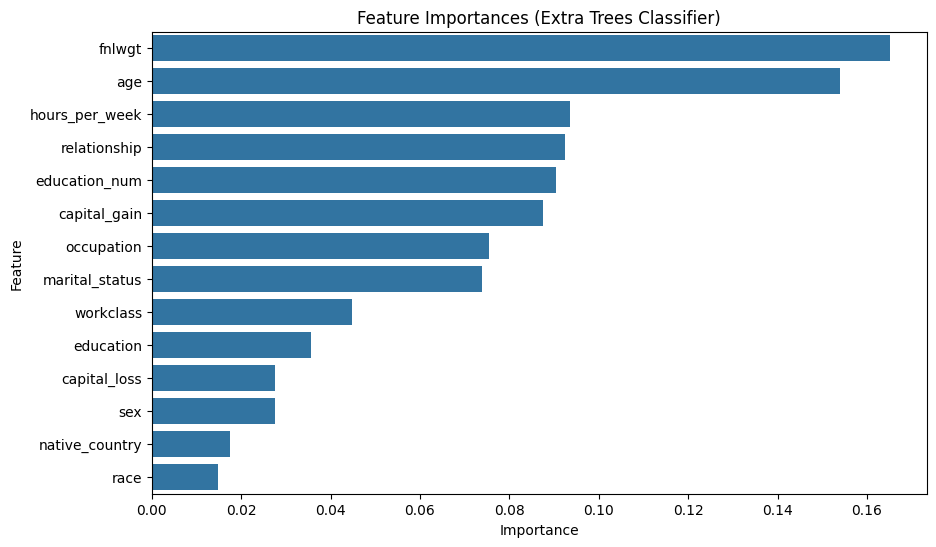

In [36]:
# --- Feature Selection with Extra Trees ---
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import LabelEncoder


# Temporarily handle missing values for feature selection
X_temp = data_set.drop('income', axis=1).fillna('Unknown')  # Replace NaN with 'Unknown'
y_temp = data_set['income'].apply(lambda x: 1 if x.strip() == '>50K' else 0)  # Binary encode target

# Label encode categorical features (ExtraTrees requires numeric input)
label_encoders = {}
for col in X_temp.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_temp[col] = le.fit_transform(X_temp[col])
    label_encoders[col] = le

# Fit ExtraTreesClassifier
extra_trees = ExtraTreesClassifier(random_state=42)
extra_trees.fit(X_temp, y_temp)

# Get feature importances
feature_importances = pd.DataFrame({
    'Feature': X_temp.columns,
    'Importance': extra_trees.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importances (Extra Trees Classifier):")
print(feature_importances)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importances (Extra Trees Classifier)')
plt.show()

# Drop low-importance features (e.g., 'race', 'native.country' as per the paper)
data_set = data_set.drop(['race', 'native_country'], axis=1)

Summary

Sex:- Out of total male 30% of them earn salary more than 50K while less than 15% female earn more than 50K. 89% female earn less than 50K
Race:- White and asain-pac-Islander earn salary more than 50K
marital_status :- 41% of married people seem to earn salary greater than 50K.
People having degree doctorate,prof-school,masters are making salary more than 50K.
Out of all the workclass only 59% self employed people are making salary more than 50K.
If I check by occupation, Proportion of people making salary less than 50K is higher

strong correlation.

Age and Hours per week
capital gain and hours per week
Moderate Correlation

capital loss and age

In [37]:
#cleaning the data and pre process for training

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Strip whitespace from object type columns
data_set = data_set.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Replace '?' with NaN for easier handling
data_set.replace('?', np.nan, inplace=True)

# Check for missing values
print(data_set.isnull().sum())

# Separate features and target
X = data_set.drop('income', axis=1)
y = data_set['income']

# After dropping features, redefine categorical/numerical columns
categorical_features = data_set.select_dtypes(include=['object']).columns.tolist()
categorical_features.remove('income')  # Ensure 'income' is not included
numerical_features = data_set.select_dtypes(include=['int64', 'float64']).columns.tolist()

# # Categorical and numerical features
# categorical_features = X.select_dtypes(include=['object']).columns.tolist()
# numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Preprocessing Pipelines
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

# Combine into a ColumnTransformer
from sklearn.compose import make_column_transformer
preprocessor = make_column_transformer(
    (numerical_pipeline, numerical_features),
    (categorical_pipeline, categorical_features)
)

# Transform the data
X_preprocessed = preprocessor.fit_transform(X)

# Encode the target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y_encoded, test_size=0.2, random_state=42)

print("Preprocessing complete. Training set shape:", X_train.shape)



C:\Users\Shanv\AppData\Local\Temp\ipykernel_38044\569170831.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data_set = data_set.applymap(lambda x: x.strip() if isinstance(x, str) else x)


age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
income               0
dtype: int64
Preprocessing complete. Training set shape: (26048, 59)


For columns like workclass, occupation, and native-country:
All '?' entries are replaced with a new category (e.g., 'Unknown').
This avoids data loss from dropping rows.

For columns like workclass, occupation, and native-country:
All '?' entries are replaced with a new category (e.g., 'Unknown').
This avoids data loss from dropping rows.

Based on Extra Trees Classifier and domain insight:
Features like race, native-country, and fnlwgt are dropped because they:
The target column (income) is separated and label-encoded:
<=50K → 0
>50K → 1



In [38]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve, auc


In [39]:
# Implement some basic classifiers such as svm and logistic regression and show the difference

# implementing svm classifier
from sklearn.svm import SVC
svm_classifier = SVC(probability=True)
svm_classifier.fit(X_train,y_train)

y_predTest_svm = svm_classifier.predict(X_test)
y_presTrain_svm = svm_classifier.predict(X_train)
score = accuracy_score(y_test,y_predTest_svm)

print(f"Test accuracy:{score}")
print(classification_report(y_predTest_svm,y_test))
score = accuracy_score(y_train,y_presTrain_svm)
print(f"Train accuracy:{score}")
print(classification_report(y_presTrain_svm,y_train))



Test accuracy:0.7959465684016582
              precision    recall  f1-score   support

           0       1.00      0.79      0.88      6295
           1       0.14      0.98      0.24       218

    accuracy                           0.80      6513
   macro avg       0.57      0.88      0.56      6513
weighted avg       0.97      0.80      0.86      6513

Train accuracy:0.7946867321867321
              precision    recall  f1-score   support

           0       1.00      0.79      0.88     25050
           1       0.15      0.98      0.27       998

    accuracy                           0.79     26048
   macro avg       0.58      0.88      0.57     26048
weighted avg       0.97      0.79      0.86     26048



In [40]:
# implementing logitic regression

from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression()
logistic_regression.fit(X_train,y_train)

y_predTest_lr = logistic_regression.predict(X_test)
y_predTrain_lr = logistic_regression.predict(X_train)

score = accuracy_score(y_test,y_predTest_lr)

print(f"Test accuracy:{score}")
print(classification_report(y_predTest_lr,y_test))
score = accuracy_score(y_train,y_predTrain_lr)
print(f"Train accuracy:{score}")
print(classification_report(y_predTrain_lr,y_train))


c:\Users\Shanv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Test accuracy:0.7980961154613849
              precision    recall  f1-score   support

           0       0.97      0.81      0.88      5971
           1       0.25      0.70      0.37       542

    accuracy                           0.80      6513
   macro avg       0.61      0.76      0.62      6513
weighted avg       0.91      0.80      0.84      6513

Train accuracy:0.7966446560196561
              precision    recall  f1-score   support

           0       0.97      0.80      0.88     23739
           1       0.26      0.72      0.38      2309

    accuracy                           0.80     26048
   macro avg       0.62      0.76      0.63     26048
weighted avg       0.90      0.80      0.83     26048



In [41]:
# implementing decision tree classifier

from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train,y_train)

y_predTest_dt = decision_tree.predict(X_test)
y_predTrain_dt = decision_tree.predict(X_train)

score = accuracy_score(y_test,y_predTest_dt)

print(f"Test accuracy:{score}")
print(classification_report(y_predTest_dt,y_test))
score = accuracy_score(y_train,y_predTrain_dt)
print(f"Train accuracy:{score}")
print(classification_report(y_predTrain_dt,y_train))


Test accuracy:0.814985413787809
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      4945
           1       0.62      0.61      0.61      1568

    accuracy                           0.81      6513
   macro avg       0.75      0.74      0.75      6513
weighted avg       0.81      0.81      0.81      6513

Train accuracy:0.9999616093366094
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19745
           1       1.00      1.00      1.00      6303

    accuracy                           1.00     26048
   macro avg       1.00      1.00      1.00     26048
weighted avg       1.00      1.00      1.00     26048



In [42]:
# implementing random forest classifier

from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)

y_predTest_rf = random_forest.predict(X_test)
y_predTrain_rf = random_forest.predict(X_train)

score = accuracy_score(y_test,y_predTest_rf)

print(f"Test accuracy:{score}")
print(classification_report(y_predTest_rf,y_test))
score = accuracy_score(y_train,y_predTrain_rf)
print(f"Train accuracy:{score}")
print(classification_report(y_predTrain_rf,y_train))


Test accuracy:0.8487640104406572
              precision    recall  f1-score   support

           0       0.92      0.88      0.90      5185
           1       0.61      0.71      0.66      1328

    accuracy                           0.85      6513
   macro avg       0.77      0.80      0.78      6513
weighted avg       0.86      0.85      0.85      6513

Train accuracy:0.9999616093366094
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19745
           1       1.00      1.00      1.00      6303

    accuracy                           1.00     26048
   macro avg       1.00      1.00      1.00     26048
weighted avg       1.00      1.00      1.00     26048



Gradient Boosting is an ensemble learning technique that combines the predictions of many weak learners (typically shallow decision trees) in a sequential way to build a strong classifier.


Start with a weak model (like a stump/tree).

Calculate the error (residuals).

Fit a new model on those errors.

Add this new model to the overall ensemble.

Repeat this process — each model fixes the mistakes of the previous one

In [43]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.model_selection import GridSearchCV

# ----------- Step 1: Grid Search for Hyperparameter Tuning -----------
param_grid = {
    'n_estimators': [250],
    'max_depth': [ 4, 5],
    'learning_rate': [0.07, 0.1]
}


gbc = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(estimator=gbc, param_grid=param_grid, 
                           scoring='accuracy', cv=5, verbose=1, n_jobs=-1)

grid_search.fit(X_train, y_train)

# Print best parameters
print("Best Parameters from GridSearchCV:")
print(grid_search.best_params_)

# ----------- Step 2: Evaluate Best Estimator -----------
best_gbc = grid_search.best_estimator_

y_pred_best = best_gbc.predict(X_test)
y_proba_best = best_gbc.predict_proba(X_test)[:, 1]

print("🔹 Gradient Boosting Classifier Report (Best Model):")
print(classification_report(y_test, y_pred_best))
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("AUROC:", roc_auc_score(y_test, y_proba_best))


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters from GridSearchCV:
{'learning_rate': 0.07, 'max_depth': 5, 'n_estimators': 250}
🔹 Gradient Boosting Classifier Report (Best Model):
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      4976
           1       0.79      0.64      0.70      1537

    accuracy                           0.87      6513
   macro avg       0.84      0.79      0.81      6513
weighted avg       0.87      0.87      0.87      6513

Accuracy: 0.8737908797789037
AUROC: 0.9273243514216318


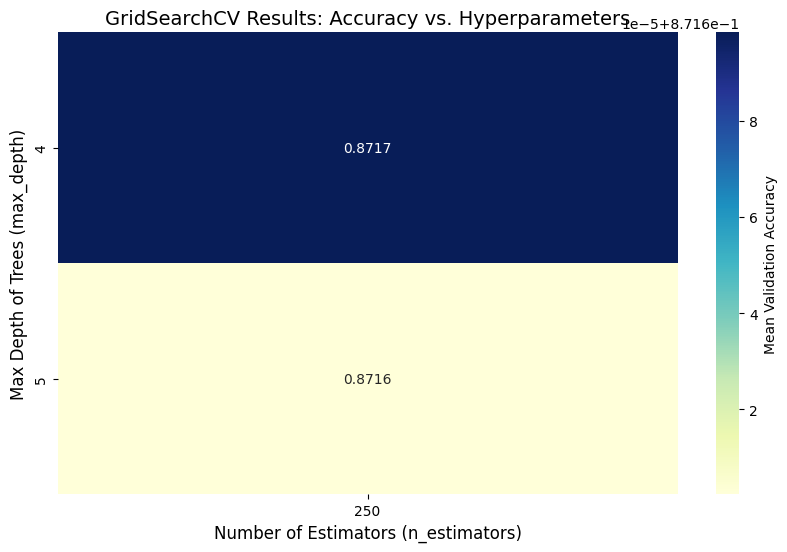

In [44]:
import seaborn as sns

# Extract GridSearchCV results into a DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

# Pivot the results for heatmap (example: max_depth vs. n_estimators)
heatmap_data = cv_results.pivot_table(
    index='param_max_depth', 
    columns='param_n_estimators', 
    values='mean_test_score'
)

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".4f", 
    cmap="YlGnBu",
    cbar_kws={'label': 'Mean Validation Accuracy'}
)
plt.title("GridSearchCV Results: Accuracy vs. Hyperparameters", fontsize=14)
plt.xlabel("Number of Estimators (n_estimators)", fontsize=12)
plt.ylabel("Max Depth of Trees (max_depth)", fontsize=12)
plt.show()

In [45]:
########## XGBoost ###############
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Initialize XGBoost

xgb = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)

# Hyperparameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [200, 250],       # Near paper's 250
    'max_depth': [  6, 7],           # Paper used max_depth=4
    'learning_rate': [0.08, 0.1],     # Paper's 0.1
    'subsample': [0.8, 1.0],               # Disable subsampling
    'colsample_bytree': [0.8, 1.0],        # Use all features
    'reg_alpha': [0, 0.1],            # Optional: L1 regularization
    'reg_lambda': [0, 0.1]            # Optional: L2 regularization
    # 'scale_pos_weight': [3.15]            # From your imbalance ratio

}

# GridSearchCV for XGBoost
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(X_train, y_train)

# Best model
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Evaluation
print("🔹 XGBoost (Best Model) Report:")
print(classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("AUROC:", roc_auc_score(y_test, y_proba_xgb))
print("Best Parameters:", grid_xgb.best_params_)

Fitting 5 folds for each of 128 candidates, totalling 640 fits


c:\Users\Shanv\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:50:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔹 XGBoost (Best Model) Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4976
           1       0.78      0.64      0.71      1537

    accuracy                           0.87      6513
   macro avg       0.84      0.79      0.81      6513
weighted avg       0.87      0.87      0.87      6513

Accuracy: 0.8737908797789037
AUROC: 0.9287946489277356
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'subsample': 1.0}


In [46]:
##########light BGM #############
from lightgbm import LGBMClassifier

# Initialize LightGBM
lgbm = LGBMClassifier(random_state=42)

# Hyperparameter grid for LightGBM
param_grid_lgbm = {
    'n_estimators': [250, 200],
    'max_depth': [ 6,7],
    'learning_rate': [0.075, 0.074],
    'num_leaves': [31, 63],
    'subsample': [0.8, 1.0],
}

# GridSearchCV for LightGBM
grid_lgbm = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid_lgbm,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_lgbm.fit(X_train, y_train)

# Best model
best_lgbm = grid_lgbm.best_estimator_
y_pred_lgbm = best_lgbm.predict(X_test)
y_proba_lgbm = best_lgbm.predict_proba(X_test)[:, 1]

# Evaluation
print("🔹 LightGBM (Best Model) Report:")
print(classification_report(y_test, y_pred_lgbm))
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("AUROC:", roc_auc_score(y_test, y_proba_lgbm))
print("Best Parameters:", grid_lgbm.best_params_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[LightGBM] [Info] Number of positive: 6304, number of negative: 19744
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002396 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 688
[LightGBM] [Info] Number of data points in the train set: 26048, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.242015 -> initscore=-1.141665
[LightGBM] [Info] Start training from score -1.141665
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

In [47]:
from sklearn.ensemble import VotingClassifier

# Reuse all trained models (ensure they are fitted)
voting_clf = VotingClassifier(
    estimators=[
        # ('lr', logistic_regression),
        # ('dt', decision_tree),
        # ('rf', random_forest),
        ('gbc', best_gbc),  # From your existing GradientBoosting
        ('xgb', best_xgb),   # XGBoost
        ('lgbm', best_lgbm)  # LightGBM
    ],
    voting='soft',
    weights=[0.4, 0.3, 0.3]
)

# Train the ensemble
voting_clf.fit(X_train, y_train)

# Evaluate
y_pred_voting = voting_clf.predict(X_test)
y_proba_voting = voting_clf.predict_proba(X_test)[:, 1]

print("🔹 Voting Classifier (XGBoost + LightGBM) Report:")
print(classification_report(y_test, y_pred_voting))
print("Accuracy:", accuracy_score(y_test, y_pred_voting))
print("AUROC:", roc_auc_score(y_test, y_proba_voting))

c:\Users\Shanv\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:55:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 6304, number of negative: 19744
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001175 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 688
[LightGBM] [Info] Number of data points in the train set: 26048, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.242015 -> initscore=-1.141665
[LightGBM] [Info] Start training from score -1.141665
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [48]:
# Collect all model names and their test accuracies
model_names = [
    'Support Vector Machine',
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting (GBC)',
    'XGBoost',
    'LightGBM',
    'Voting Classifier'
]

test_accuracies = [
    accuracy_score(y_test, y_predTest_svm),
    accuracy_score(y_test, y_predTest_lr),
    accuracy_score(y_test, y_predTest_dt),
    accuracy_score(y_test, y_predTest_rf),  
    accuracy_score(y_test, y_pred_best),
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test, y_pred_lgbm),
    accuracy_score(y_test, y_pred_voting)
]

# Create DataFrame and display
import pandas as pd
results_df = pd.DataFrame({
    'Model': model_names,
    'Test Accuracy': [f"{acc*100:.2f}%" for acc in test_accuracies]
})
print("Model Performance Summary:")
print(results_df.to_string(index=False))

Model Performance Summary:
                  Model Test Accuracy
 Support Vector Machine        79.59%
    Logistic Regression        79.81%
          Decision Tree        81.50%
          Random Forest        84.88%
Gradient Boosting (GBC)        87.38%
                XGBoost        87.38%
               LightGBM        87.21%
      Voting Classifier        87.46%


In [49]:
import pickle

# After training your model
with open('finalmodel.pkl', 'wb') as f:
    pickle.dump(voting_clf, f)
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)
